In [1]:
pwd

'D:\\樓上志偉\\2025實測\\notebooks'

In [2]:
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sns

pd.options.mode.copy_on_write = True
fm.fontManager.addfont('..\\TaipeiSansTCBeta-Regular.ttf')
plt.rcParams["font.size"] = 14
plt.rcParams['font.family'] = 'Taipei Sans TC Beta'

In [3]:
# testing_load = "HALF_LOAD"
testing_load = "FULL_LOAD"
# testing_load_c = "半載"
testing_load_c = "全載"

df = pd.read_csv(f'..\\data\\raw\\偉仁26噸\\B114AS0005_0327_FUEL_CONSUMPTION_{testing_load}_1ST.csv', header=2,
                 usecols=['GPS_VehicleSpeed', 'OBD_EngineSpeed', 'OBD_EngineFuelRate'])
df.columns = ['VehicleSpeed[km/h]', 'EngineSpeed[rpm]', 'EngineFuelRate[L/h]']

In [4]:
df['grad[%]'] = 0.

In [5]:
df['time[s]'] = [i for i in range(1, len(df)+1)]

df['acc[m/s^2]'] = (df.loc[0, 'VehicleSpeed[km/h]'] - 0.) / 3.6 # 資料為逐秒紀錄
for i in range(1, len(df)):
    df.loc[i, 'acc[m/s^2]'] = (df.loc[i, 'VehicleSpeed[km/h]'] - df.loc[i-1, 'VehicleSpeed[km/h]']) / 3.6

# 全載(90%)車重: 14975+(26000-14975)*0.9=24897.5, 半載(55%)車重: 14975+(26000-14975)*0.55=21038.75
if testing_load == "HALF_LOAD":
    df['W[kg]'] = 14975+(26000-14975)*0.55
else:
    df['W[kg]'] = 14975+(26000-14975)*0.9

density_deisel = 836. # 柴油密度[kg/m3] @ VECTO
df['EngineFuelRate[g/h]'] = df['EngineFuelRate[L/h]'] / 1000. * density_deisel * 1000.
df.head()

,VehicleSpeed[km/h],EngineSpeed[rpm],EngineFuelRate[L/h],grad[%],time[s],acc[m/s^2],W[kg],EngineFuelRate[g/h]
0,0.157,502.50,1.60,0.0,1,0.043611,24897.5,1337.60002
1,0.130,502.00,1.60,0.0,2,-0.007500,24897.5,1337.60002
2,0.088,500.25,1.65,0.0,3,-0.011667,24897.5,1379.39998
3,0.159,498.50,1.70,0.0,4,0.019722,24897.5,1421.20004
4,0.095,497.25,1.80,0.0,5,-0.017778,24897.5,1504.79996


In [6]:
B = 2.6 # 車寬[m]
H = 3.75 # 車高[m]

# 變速箱齒比
i_m_1_16 = {1:14.68, 2:12.05, 3:9.92, 4:8.14, 5:6.78, 6:5.56, 7:4.57, 8:3.75, 9:3.22, 10:2.64, 11:2.17, 12:1.78, 13:1.49, 14:1.22, 15:1, 16:0.82}
i_f = 3.727 # 差速器減速比
eff_m = 0.98 # 傳動效率
eff_f = 0.95

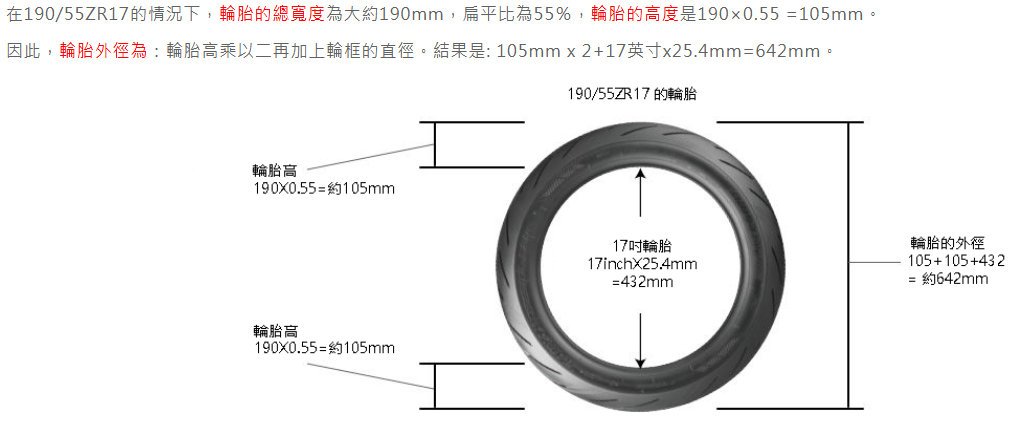

In [7]:
# driven wheels: 318/80 R22.5
wheel_D = (318*0.80*2 + 22.5*25.4) / 1000. # [m]
r = wheel_D / 2 # [m]

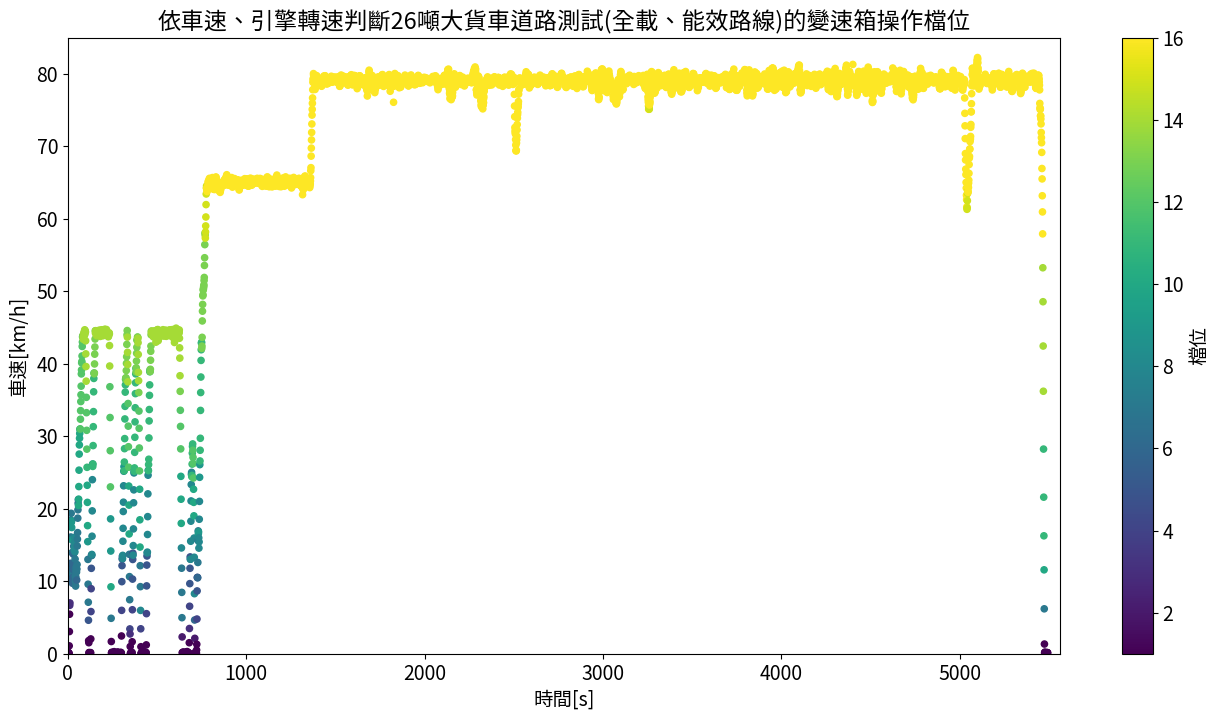

In [8]:
# 檔位判斷
# 忽略空檔、換檔間的操作情況
def v_to_n(v, g):
    """ 從車速[km/h]、檔位g，計算引擎轉速[rpm] """
    if gear_ratio := i_m_1_16.get(g):
        return (v*1000./60.) / (wheel_D*np.pi) * i_f * gear_ratio
    else:
        print("Gear Position Error!")

def predit_gear_position(v, n):
    """ 從車速[km/h]，計算1~16檔的可能引擎轉速，並取出最接近引擎轉速的檔位 """
    l=[]
    for g in range(1, 17):
        l.append(abs(v_to_n(v,g)-n))
    return l.index(min(l))+1

df['predit_gear_position'] = df.apply(lambda x: predit_gear_position(x['VehicleSpeed[km/h]'], x['EngineSpeed[rpm]']), axis=1)
df['i_m'] = df['predit_gear_position'].apply(lambda x :i_m_1_16.get(x))


fig, ax = plt.subplots(figsize=(16, 8))
norm = matplotlib.colors.Normalize(vmin=1, vmax=16)
sc = ax.scatter(df['time[s]'], df['VehicleSpeed[km/h]'], c=df['predit_gear_position'], cmap='viridis', s=20, norm=norm)
ax.set_xlabel('時間[s]')
ax.set_ylabel('車速[km/h]')
ax.set_xlim(0,5560)
ax.set_ylim(0,85)
plt.title(f"依車速、引擎轉速判斷26噸大貨車道路測試({testing_load_c}、能效路線)的變速箱操作檔位")
plt.colorbar(sc, label='檔位')

plt.show()

# TRIAS 08-003-02 燃料消費率試驗(重量車)

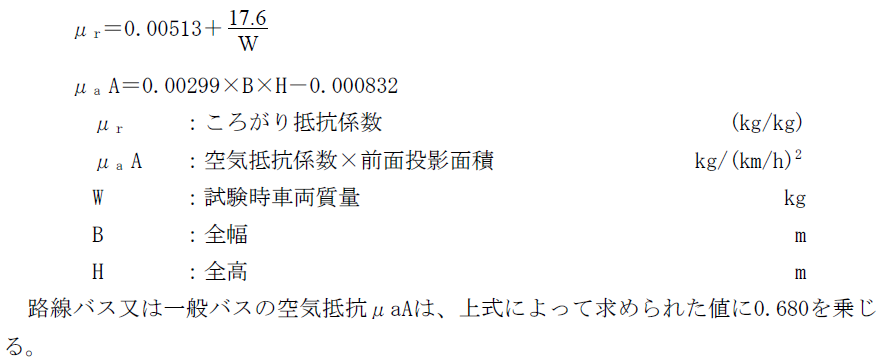

In [9]:
df['mu_r[kg/kg]'] = 0.00513 + 17.6 / df['W[kg]']
df['mu_aA[kg/(km/h)2]'] = 0.00299 * B * H - 0.000832

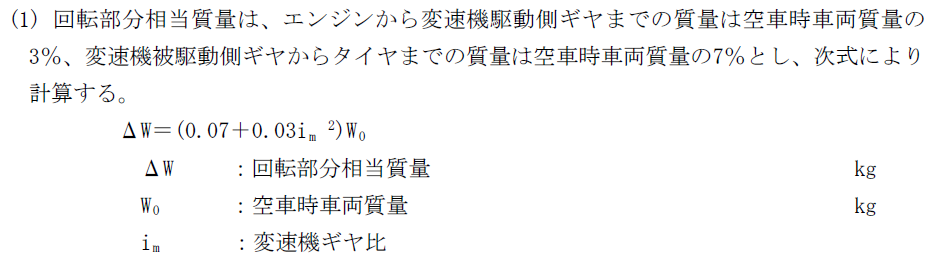

In [10]:
W0 = 14975 # 空車重[kg]
df['W_eq[kg]'] = (0.07 + 0.03*df['i_m']*df['i_m']) * W0

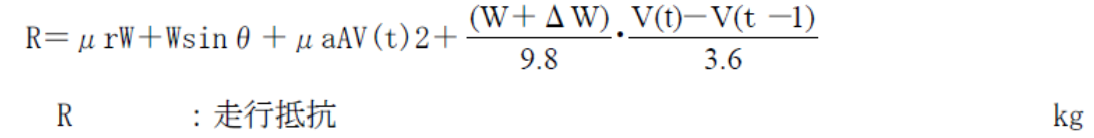

In [11]:
df['F_rr[N]'] = df['mu_r[kg/kg]'] * df['W[kg]'] * 9.81 # 調整單位為N
df['F_slope[N]'] = df['W[kg]'] * np.sin(np.arctan(df['grad[%]'] / 100)) * 9.81
df['F_air[N]'] = df['mu_aA[kg/(km/h)2]'] * df['VehicleSpeed[km/h]'] * df['VehicleSpeed[km/h]'] * 9.81
df['F_acc[N]'] = (df['W[kg]'] + df['W_eq[kg]']) * df['acc[m/s^2]']

df['R[N]'] = df['F_rr[N]'] + df['F_slope[N]'] + df['F_air[N]'] +df['F_acc[N]']

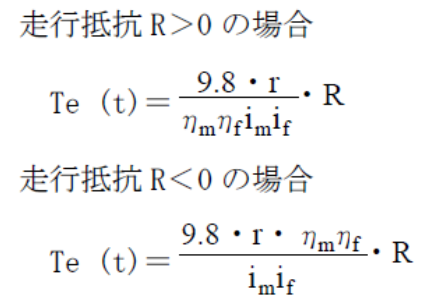

In [12]:
def engine_torque(R, i_m): # 此R的單位為[N]
    if R>=0: # 原稿為R>0
        return r / eff_m / eff_f / i_m / i_f * R
    else:
        return r * eff_m * eff_f / i_m / i_f * R

df['engine_torque[Nm]'] = df.apply(lambda x: engine_torque(x['R[N]'], x['i_m']), axis=1)
df['engine_power[kW]'] = df['engine_torque[Nm]'] * (df['EngineSpeed[rpm]'] * 2. * np.pi / 60.) / 1000.

# 制動馬力單位油耗量(Brake Specific Fuel Consumption, BSFC)
df['BSFC[g/kW-h]'] = df['EngineFuelRate[g/h]'] / df['engine_power[kW]']

NCV = 42700 # 柴油熱值NCV為42700 kJ/kg @ VECTO

# 制動熱效率(Brake Thermal Efficiency, BTE)
df['BTE'] = 1. / df['BSFC[g/kW-h]'] * 3600 * 1000 / NCV

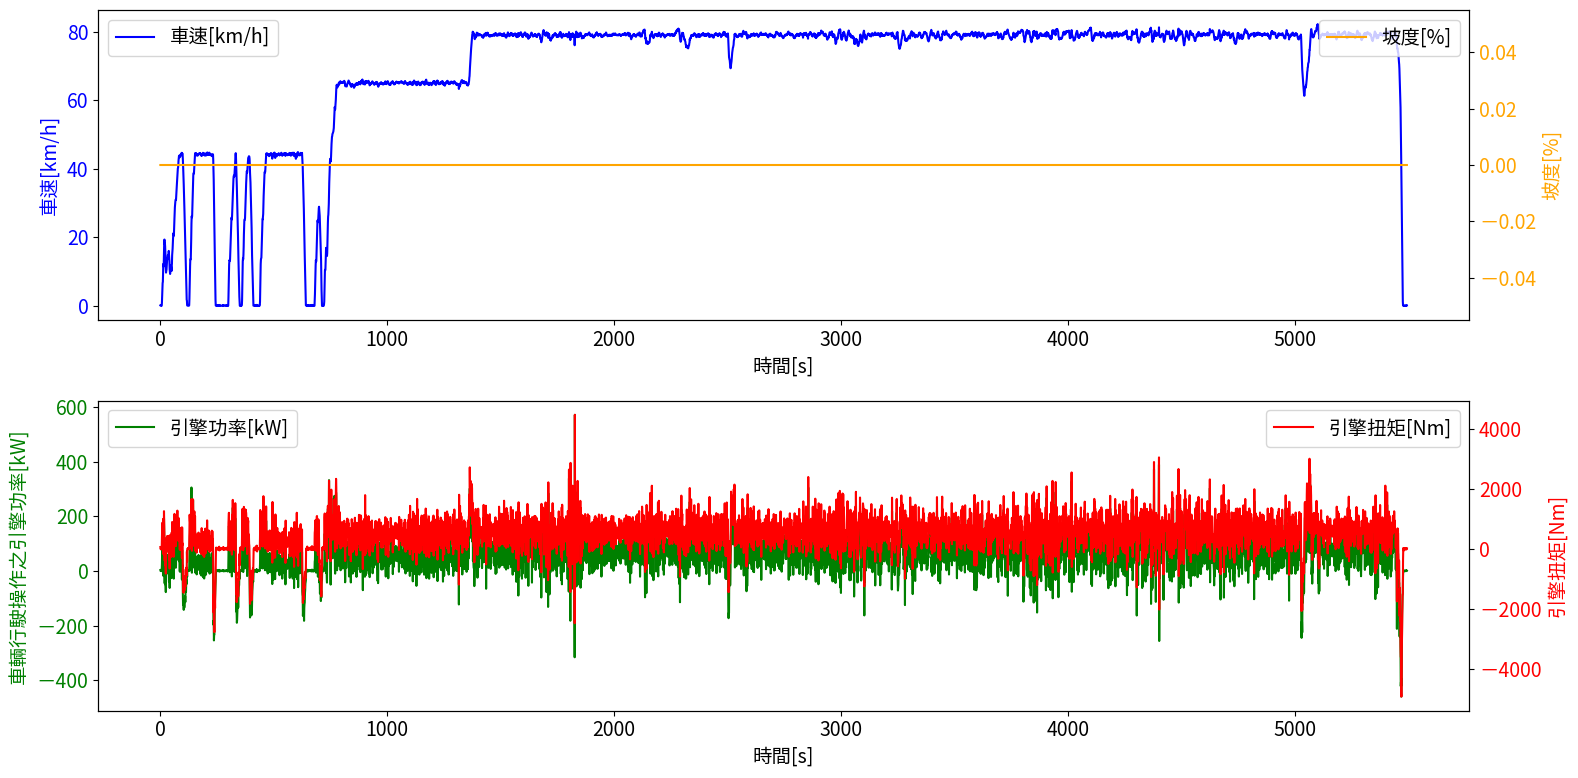

In [15]:
fig, ax = plt.subplots(2, 1, figsize=(16, 8))

ax[0].plot(df['time[s]'], df['VehicleSpeed[km/h]'], label='車速[km/h]', color='blue')
ax[0].set_xlabel('時間[s]')
ax[0].set_ylabel('車速[km/h]', color='blue')
ax[0].tick_params(axis='y', labelcolor='blue')
# ax[0].set_xlim(0, 1750)
ax[0].legend()#loc='upper left')

ax2 = ax[0].twinx()
ax2.plot(df['time[s]'], df['grad[%]'], label='坡度[%]', color='orange')
ax2.set_ylabel('坡度[%]', color='orange')
# ax2.set_ylim(-20, 20)
ax2.tick_params(axis='y', labelcolor='orange')
ax[0].legend(loc='upper left')
ax2.legend()#loc='upper right')

ax[1].plot(df['time[s]'], df['engine_power[kW]'], label='引擎功率[kW]', color='green')
ax[1].set_xlabel('時間[s]')
ax[1].set_ylabel('車輛行駛操作之引擎功率[kW]', color='green')
ax[1].tick_params(axis='y', labelcolor='green')
# ax[1].set_xlim(0, 1750)
ax[1].legend()

ax4 = ax[1].twinx()
ax4.plot(df['time[s]'], df['engine_torque[Nm]'], label='引擎扭矩[Nm]', color='red')
ax4.set_ylabel('引擎扭矩[Nm]', color='red')
ax4.tick_params(axis='y', labelcolor='red')
ax[1].legend(loc='upper left')
ax4.legend(loc='upper right')

plt.tight_layout()
plt.show()

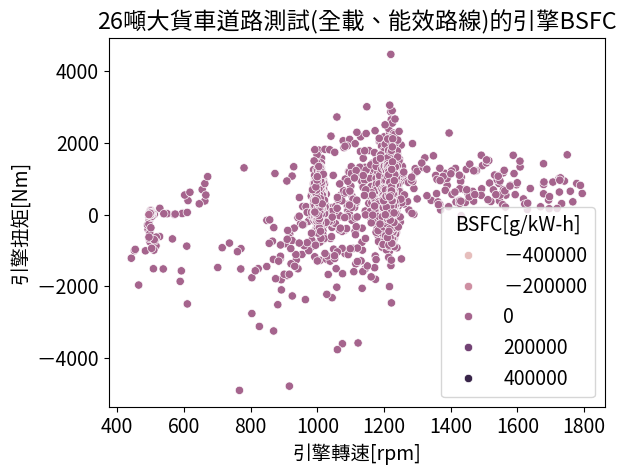

In [16]:
fig = plt.figure()
sns.scatterplot(data=df,
                x="EngineSpeed[rpm]",
                y="engine_torque[Nm]",
                hue="BSFC[g/kW-h]")

plt.title(f"26噸大貨車道路測試({testing_load_c}、能效路線)的引擎BSFC")
# plt.ylim(0,3000)
plt.xlabel('引擎轉速[rpm]')
plt.ylabel('引擎扭矩[Nm]')
# plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

In [17]:
df['P_rr[kW]'] = df['F_rr[N]'] / 1000. * df['VehicleSpeed[km/h]'] / 3.6
df['P_air[kW]'] = df['F_air[N]'] / 1000. * df['VehicleSpeed[km/h]'] / 3.6
df['P_acc[kW]'] = df['F_acc[N]'] / 1000. * df['VehicleSpeed[km/h]'] /3.6
df['P_slope[kW]'] = df['F_slope[N]'] / 1000. * df['VehicleSpeed[km/h]'] /3.6

df['vehile_power[kW]'] = df['R[N]'] / 1000 * df['VehicleSpeed[km/h]'] / 3.6

In [ ]:
df.to_csv(f"..\\data\\processed\\26噸大貨車{testing_load_c}能效路線空氣動力學計算_0327_1.csv", encoding= 'utf-8-sig', index=False)

### 暫態數據合理性討論：
### 由引擎制動熱效率篩選數據(註: 篩後部分時間會斷片。)

In [19]:
# 按0<BTE<1篩選
print(f"原數據有{len(df)}筆，篩選後有{len(df[(df['BTE']<1)&(df['BTE']>0)])}筆，計篩除{(1-len(df[(df['BTE']<1)&(df['BTE']>0)])/len(df))*100:.2f}%數據。")

# 柴油引擎熱效率範圍在30%~45%
# 燃燒過程缸內溫度在1800-2000攝氏度，而正常工作引擎水溫在80-95攝氏度。
# 依卡諾熱機(Carnot)估算 熱效率1-368.15/2273.15=83.8%
print(1-353.15/2073.15 ,1-368.15/2273.15)
print(f"原數據有{len(df)}筆，篩選後有{len(df[(df['BTE']<0.838)&(df['BTE']>0)])}筆，計篩除{(1-len(df[(df['BTE']<0.838)&(df['BTE']>0)])/len(df))*100:.2f}%數據。")

原數據有5492筆，篩選後有4254筆，計篩除22.54%數據。
0.8296553553770832 0.8380441237929745
原數據有5492筆，篩選後有4122筆，計篩除24.95%數據。


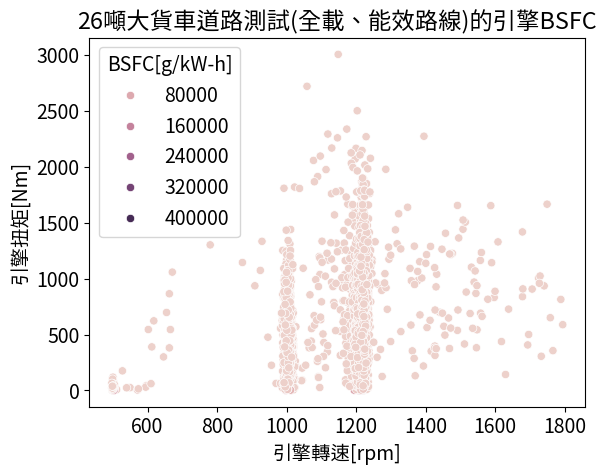

In [20]:
fig = plt.figure()
sns.scatterplot(data=df[(df['BTE']<0.838)&(df['BTE']>0)],
                x="EngineSpeed[rpm]",
                y="engine_torque[Nm]",
                hue="BSFC[g/kW-h]")

plt.title(f"26噸大貨車道路測試({testing_load_c}、能效路線)的引擎BSFC")
# plt.ylim(0,3000)
plt.xlabel('引擎轉速[rpm]')
plt.ylabel('引擎扭矩[Nm]')
# plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

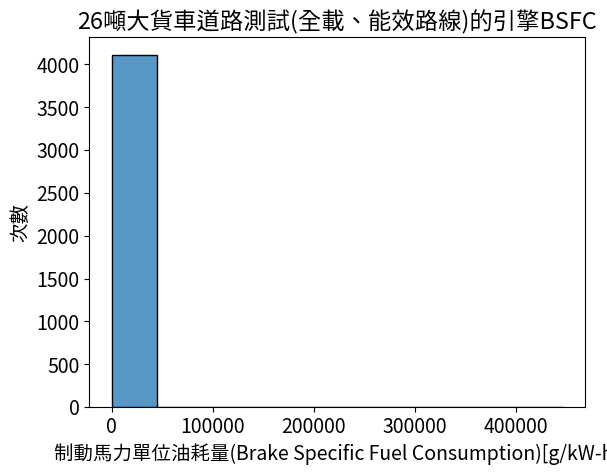

In [21]:
fig = plt.figure()
sns.histplot(data=df[(df['BTE']<0.838)&(df['BTE']>0)], x='BSFC[g/kW-h]', bins=10)#, kde=True)
plt.title(f"26噸大貨車道路測試({testing_load_c}、能效路線)的引擎BSFC")

plt.xlabel('制動馬力單位油耗量(Brake Specific Fuel Consumption)[g/kW-h]')
plt.ylabel('次數')
plt.show()

In [22]:
df[['VehicleSpeed[km/h]', 'EngineSpeed[rpm]', 'acc[m/s^2]','F_rr[N]', 'F_slope[N]', 'F_air[N]', 'F_acc[N]', 'R[N]',
       'engine_torque[Nm]', 'engine_power[kW]']].describe().round(0).astype(int)

,VehicleSpeed[km/h],EngineSpeed[rpm],acc[m/s^2],F_rr[N],F_slope[N],F_air[N],F_acc[N],R[N],engine_torque[Nm],engine_power[kW]
count,5492,5492,5492,5492,5492,5492,5492,5492,5492,5492
mean,70,1156,0,1426,0,1457,11,2894,522,66
std,20,163,0,0,0,528,7567,7589,573,69
min,0,442,-2,1426,0,0,-165760,-164334,-4902,-459
25%,66,1184,0,1426,0,1194,-1553,1386,217,26
50%,79,1216,0,1426,0,1728,84,3058,549,68
75%,79,1223,0,1426,0,1747,1707,4689,850,106
max,82,1794,1,1426,0,1880,81567,83001,4468,571


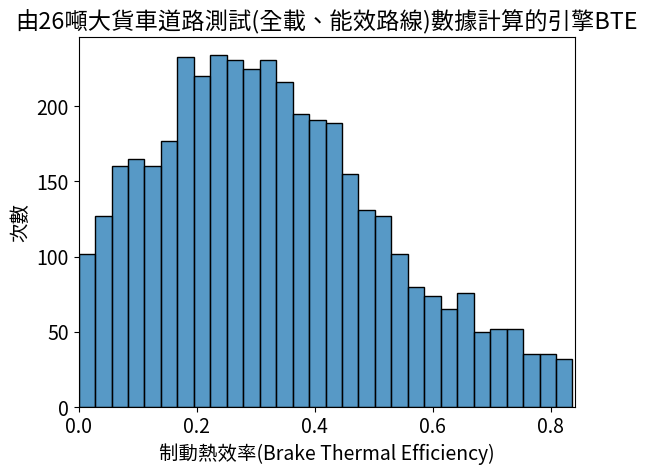

In [23]:
fig = plt.figure()
sns.histplot(data=df[(df['BTE']<0.838)&(df['BTE']>0)], x='BTE', bins=30)
plt.title(f"由26噸大貨車道路測試({testing_load_c}、能效路線)數據計算的引擎BTE")

plt.xlabel('制動熱效率(Brake Thermal Efficiency)')
plt.ylabel('次數')
plt.xlim(0, 0.84)
plt.show()

In [24]:
print(f"{len(df)}筆數據：")
E_fuel = df['EngineFuelRate[L/h]'].sum() / 3600 / 1000. * density_deisel * NCV
print(f"使用燃油的能量{E_fuel:.0f} kJ")
E_rr = df['P_rr[kW]'].sum()
print()

print(f"克服滾阻耗能{E_rr:.0f} kJ")
E_air = df['P_air[kW]'].sum()
print(f"克服風阻耗能{E_air:.0f} kJ")
E_acc = df['P_acc[kW]'].sum()
print(f"加減速使用能量{E_acc:.0f} kJ")
E_slope = df['P_slope[kW]'].sum()
print(f"上下坡使用能量{E_slope:.0f} kJ")
print()

print(f"假設引擎熱效率為40%，引擎輸出功為{E_fuel*0.4:.0f} kJ")
print(f"滾阻耗能占引擎輸出功比例{E_rr/(E_fuel*0.4)*100:.1f}")
print(f"風阻耗能占引擎輸出功比例{E_air/(E_fuel*0.4)*100:.1f}")
print(f"加減速使用能量占引擎輸出功比例{E_acc/(E_fuel*0.4)*100:.1f}")
print(f"上下坡使用能量占引擎輸出功比例{E_slope/(E_fuel*0.4)*100:.1f}")
print(f"其他能量損失占引擎輸出功比例{(E_fuel*0.4-E_rr-E_air-E_acc-E_slope)/(E_fuel*0.4)*100:.1f}")

5492筆數據：
使用燃油的能量1156415 kJ

克服滾阻耗能151340 kJ
克服風阻耗能170363 kJ
加減速使用能量4336 kJ
上下坡使用能量0 kJ

假設引擎熱效率為40%，引擎輸出功為462566 kJ
滾阻耗能占引擎輸出功比例32.7
風阻耗能占引擎輸出功比例36.8
加減速使用能量占引擎輸出功比例0.9
上下坡使用能量占引擎輸出功比例0.0
其他能量損失占引擎輸出功比例29.5


In [25]:
print(f"{len(df[(df['BTE']<0.838)&(df['BTE']>0)])}筆數據(引擎熱效率{df[(df['BTE']<0.838)&(df['BTE']>0)]['BTE'].mean():.3f})：")
E_fuel = df[(df['BTE']<0.838)&(df['BTE']>0)]['EngineFuelRate[L/h]'].sum() / 3600 / 1000. * density_deisel * NCV
print(f"使用燃油的能量{E_fuel:.0f} kJ")
print()

E_rr = df[(df['BTE']<0.838)&(df['BTE']>0)]['P_rr[kW]'].sum()
print(f"克服滾阻耗能{E_rr:.0f} kJ")
E_air = df[(df['BTE']<0.838)&(df['BTE']>0)]['P_air[kW]'].sum()
print(f"克服風阻耗能{E_air:.0f} kJ")
E_acc = df[(df['BTE']<0.838)&(df['BTE']>0)]['P_acc[kW]'].sum()
print(f"加減速使用能量{E_acc:.0f} kJ")
E_slope = df[(df['BTE']<0.838)&(df['BTE']>0)]['P_slope[kW]'].sum()
print(f"上下坡使用能量{E_slope:.0f} kJ")
print()

print(f"假設引擎熱效率為40%，引擎輸出功為{E_fuel*0.4:.0f} kJ")
print(f"滾阻耗能占引擎輸出功比例{E_rr/(E_fuel*0.4)*100:.1f}")
print(f"風阻耗能占引擎輸出功比例{E_air/(E_fuel*0.4)*100:.1f}")
print(f"加減速使用能量占引擎輸出功比例{E_acc/(E_fuel*0.4)*100:.1f}")
print(f"上下坡使用能量占引擎輸出功比例{E_slope/(E_fuel*0.4)*100:.1f}")
# print(f"其他能量損失占引擎輸出功比例{(E_fuel*0.4-E_rr-E_air-E_acc-E_slope)/(E_fuel*0.4)*100:.1f}")



4122筆數據(引擎熱效率0.330)：
使用燃油的能量1035648 kJ

克服滾阻耗能115516 kJ
克服風阻耗能130359 kJ
加減速使用能量45431 kJ
上下坡使用能量0 kJ

假設引擎熱效率為40%，引擎輸出功為414259 kJ
滾阻耗能占引擎輸出功比例27.9
風阻耗能占引擎輸出功比例31.5
加減速使用能量占引擎輸出功比例11.0
上下坡使用能量占引擎輸出功比例0.0


In [26]:
df[(df['BTE']<0.838)&(df['BTE']>0)][["engine_torque[Nm]", 'engine_power[kW]', "BSFC[g/kW-h]", "BTE"]].describe()
# 經熱效率篩選後，BSFC及Nm均>0。
# 仍然有BSFC很大的值，因為BSFC為EngineFuelRate[g/h] / engine_power[kW]，當engine_power[kW]很小時，BSFC會很大。
# 所計算之引擎扭力、馬力較接近26噸大貨車規格: 最大淨馬力410 ps(301.5 kW)、最大淨扭力220 kg-m(2161.7 N-m)

,engine_torque[Nm],engine_power[kW],BSFC[g/kW-h],BTE
count,4122.000000,4122.000000,4122.000000,4122.000000
mean,624.505100,78.077872,953.292523,0.330097
std,389.882751,50.340621,8998.087701,0.191548
min,0.164281,0.015293,100.781309,0.000189
25%,338.914049,40.666235,186.757443,0.184437
50%,591.432761,73.396481,272.197673,0.309735
75%,863.237866,107.584610,457.116921,0.451437
max,3007.289639,361.688646,446569.217435,0.836555


#### 模型處理：對引擎轉速、引擎扭矩取分組數nn x nn的統計代表值
#### 嘗試一：原計算資料

車速與引擎轉速分組數為2x2下，迴歸的R2為0.9235
車速與引擎轉速分組數為3x3下，迴歸的R2為0.2965
車速與引擎轉速分組數為4x4下，迴歸的R2為0.3388
車速與引擎轉速分組數為5x5下，迴歸的R2為0.1815
車速與引擎轉速分組數為6x6下，迴歸的R2為0.2302
車速與引擎轉速分組數為7x7下，迴歸的R2為0.1926
車速與引擎轉速分組數為8x8下，迴歸的R2為0.1740
車速與引擎轉速分組數為9x9下，迴歸的R2為0.1005
車速與引擎轉速分組數為10x10下，迴歸的R2為0.2113
車速與引擎轉速分組數為11x11下，迴歸的R2為0.0852
車速與引擎轉速分組數為12x12下，迴歸的R2為0.1289
車速與引擎轉速分組數為13x13下，迴歸的R2為0.0756
車速與引擎轉速分組數為14x14下，迴歸的R2為0.0717
車速與引擎轉速分組數為15x15下，迴歸的R2為0.0637

車速與引擎轉速分組數為2x2下(經填補操作)，迴歸的R2為0.9235
車速與引擎轉速分組數為3x3下(經填補操作)，迴歸的R2為0.2502
車速與引擎轉速分組數為4x4下(經填補操作)，迴歸的R2為0.3148
車速與引擎轉速分組數為5x5下(經填補操作)，迴歸的R2為0.1507
車速與引擎轉速分組數為6x6下(經填補操作)，迴歸的R2為0.1546
車速與引擎轉速分組數為7x7下(經填補操作)，迴歸的R2為0.1086
車速與引擎轉速分組數為8x8下(經填補操作)，迴歸的R2為0.1459
車速與引擎轉速分組數為9x9下(經填補操作)，迴歸的R2為0.0792
車速與引擎轉速分組數為10x10下(經填補操作)，迴歸的R2為0.1828
車速與引擎轉速分組數為11x11下(經填補操作)，迴歸的R2為0.0473
車速與引擎轉速分組數為12x12下(經填補操作)，迴歸的R2為0.1198
車速與引擎轉速分組數為13x13下(經填補操作)，迴歸的R2為0.0467
車速與引擎轉速分組數為14x14下(經填補操作)，迴歸的R2為0.0837
車速與引擎轉速分組數為15x15下(經填補操作)，迴歸的R2為0.0644


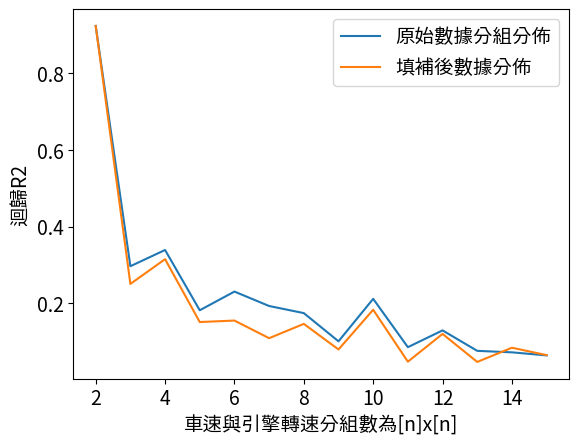

In [27]:
from sklearn.linear_model import LinearRegression
from scipy.interpolate import griddata

spacing_nn = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
r2_scores = {}
r2_scores_new = {}

for nn in spacing_nn:
    ESn = np.linspace(df['EngineSpeed[rpm]'].min(), df['EngineSpeed[rpm]'].max(), nn+1)
    ETn = np.linspace(df['engine_torque[Nm]'].min(), df['engine_torque[Nm]'].max(), nn+1)
    dfGG = df.groupby([pd.cut(df['EngineSpeed[rpm]'], bins=ESn), pd.cut(df['engine_torque[Nm]'], bins=ETn)], observed=True)['BSFC[g/kW-h]'].agg(['count', 'mean', 'median']).reset_index()
    dfGG['EngineSpeed[rpm]'] = dfGG['EngineSpeed[rpm]'].apply(lambda x: (x.left+x.right)/2)
    dfGG['engine_torque[Nm]'] = dfGG['engine_torque[Nm]'].apply(lambda x: (x.left+x.right)/2)

    X = dfGG[['EngineSpeed[rpm]', 'engine_torque[Nm]']]
    y = dfGG['median']
    
    reg = LinearRegression().fit(X, y)
    r2_scores[nn] = reg.score(X, y)
    print(f"車速與引擎轉速分組數為{nn}x{nn}下，迴歸的R2為{reg.score(X, y):.4f}")

print()

for nn in spacing_nn:    
    ESn = np.linspace(df['EngineSpeed[rpm]'].min(), df['EngineSpeed[rpm]'].max(), nn+1)
    ETn = np.linspace(df['engine_torque[Nm]'].min(), df['engine_torque[Nm]'].max(), nn+1)
    dfGG_new = df.groupby([pd.cut(df['EngineSpeed[rpm]'], bins=ESn), pd.cut(df['engine_torque[Nm]'], bins=ETn)], observed=False)['BSFC[g/kW-h]'].median().reset_index()
    dfGG_new['EngineSpeed[rpm]'] = dfGG_new['EngineSpeed[rpm]'].apply(lambda x: (x.left+x.right)/2)
    dfGG_new['engine_torque[Nm]'] = dfGG_new['engine_torque[Nm]'].apply(lambda x: (x.left+x.right)/2)
    
    dfGG_known = dfGG_new.dropna(subset=['BSFC[g/kW-h]'])
    dfGG_missing = dfGG_new[dfGG_new['BSFC[g/kW-h]'].isna()]
    
    fc_interp = griddata(
        points=dfGG_known[['EngineSpeed[rpm]', 'engine_torque[Nm]']],
        values=dfGG_known['BSFC[g/kW-h]'],
        xi=dfGG_missing[['EngineSpeed[rpm]', 'engine_torque[Nm]']],
        method='nearest'
    )
    
    dfGG_new.loc[dfGG_new['BSFC[g/kW-h]'].isna(), 'BSFC[g/kW-h]'] = fc_interp


    X = dfGG_new[['EngineSpeed[rpm]', 'engine_torque[Nm]']]
    y = dfGG_new['BSFC[g/kW-h]']
    
    reg_new = LinearRegression().fit(X, y)
    r2_scores_new[nn] = reg_new.score(X, y)
    print(f"車速與引擎轉速分組數為{nn}x{nn}下(經填補操作)，迴歸的R2為{reg_new.score(X, y):.4f}")


fig = plt.figure() 
plt.plot(spacing_nn, r2_scores.values(), label="原始數據分組分佈")
plt.plot(spacing_nn, r2_scores_new.values(), label="填補後數據分佈")
plt.xlabel('車速與引擎轉速分組數為[n]x[n]')
plt.ylabel('迴歸R2')
plt.legend()
plt.show()

### 嘗試二：取引擎扭矩>0數據

車速與引擎轉速分組數為2x2下，迴歸的R2為0.9665
車速與引擎轉速分組數為3x3下，迴歸的R2為0.7381
車速與引擎轉速分組數為4x4下，迴歸的R2為0.4830
車速與引擎轉速分組數為5x5下，迴歸的R2為0.4108
車速與引擎轉速分組數為6x6下，迴歸的R2為0.4041
車速與引擎轉速分組數為7x7下，迴歸的R2為0.4077
車速與引擎轉速分組數為8x8下，迴歸的R2為0.3163
車速與引擎轉速分組數為9x9下，迴歸的R2為0.3564
車速與引擎轉速分組數為10x10下，迴歸的R2為0.2678
車速與引擎轉速分組數為11x11下，迴歸的R2為0.3314
車速與引擎轉速分組數為12x12下，迴歸的R2為0.3706
車速與引擎轉速分組數為13x13下，迴歸的R2為0.3994
車速與引擎轉速分組數為14x14下，迴歸的R2為0.2907
車速與引擎轉速分組數為15x15下，迴歸的R2為0.2708

車速與引擎轉速分組數為2x2下(經填補操作)，迴歸的R2為0.9665
車速與引擎轉速分組數為3x3下(經填補操作)，迴歸的R2為0.5329
車速與引擎轉速分組數為4x4下(經填補操作)，迴歸的R2為0.4714
車速與引擎轉速分組數為5x5下(經填補操作)，迴歸的R2為0.3944
車速與引擎轉速分組數為6x6下(經填補操作)，迴歸的R2為0.4044
車速與引擎轉速分組數為7x7下(經填補操作)，迴歸的R2為0.3770
車速與引擎轉速分組數為8x8下(經填補操作)，迴歸的R2為0.3983
車速與引擎轉速分組數為9x9下(經填補操作)，迴歸的R2為0.4198
車速與引擎轉速分組數為10x10下(經填補操作)，迴歸的R2為0.3691
車速與引擎轉速分組數為11x11下(經填補操作)，迴歸的R2為0.4276
車速與引擎轉速分組數為12x12下(經填補操作)，迴歸的R2為0.4458
車速與引擎轉速分組數為13x13下(經填補操作)，迴歸的R2為0.4187
車速與引擎轉速分組數為14x14下(經填補操作)，迴歸的R2為0.3113
車速與引擎轉速分組數為15x15下(經填補操作)，迴歸的R2為0.2423


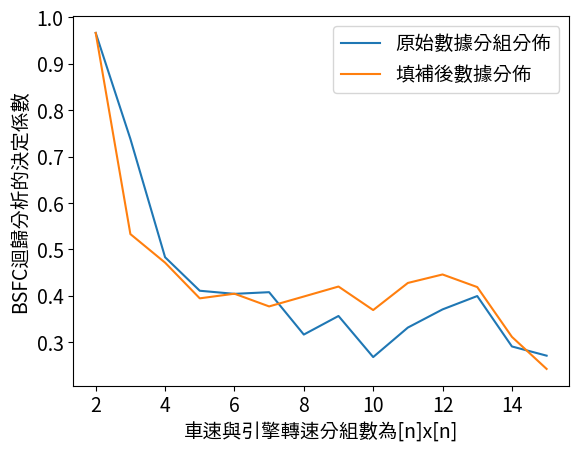

In [28]:
from sklearn.linear_model import LinearRegression
from scipy.interpolate import griddata

spacing_nn = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
r2_scores = {}
r2_scores_new = {}

for nn in spacing_nn:
    ESn = np.linspace(df[df['engine_torque[Nm]']>0]['EngineSpeed[rpm]'].min(), df[df['engine_torque[Nm]']>0]['EngineSpeed[rpm]'].max(), nn+1)
    ETn = np.linspace(df[df['engine_torque[Nm]']>0]['engine_torque[Nm]'].min(), df[df['engine_torque[Nm]']>0]['engine_torque[Nm]'].max(), nn+1)
    dfGG = df.groupby([pd.cut(df[df['engine_torque[Nm]']>0]['EngineSpeed[rpm]'], bins=ESn), pd.cut(df[df['engine_torque[Nm]']>0]['engine_torque[Nm]'], bins=ETn)], observed=True)['BSFC[g/kW-h]'].agg(['count', 'mean', 'median']).reset_index()
    dfGG['EngineSpeed[rpm]'] = dfGG['EngineSpeed[rpm]'].apply(lambda x: (x.left+x.right)/2)
    dfGG['engine_torque[Nm]'] = dfGG['engine_torque[Nm]'].apply(lambda x: (x.left+x.right)/2)

    X = dfGG[['EngineSpeed[rpm]', 'engine_torque[Nm]']]
    y = dfGG['median']
    reg = LinearRegression().fit(X, y)
    r2_scores[nn] = reg.score(X, y)
    print(f"車速與引擎轉速分組數為{nn}x{nn}下，迴歸的R2為{reg.score(X, y):.4f}")

print()

for nn in spacing_nn:    
    ESn = np.linspace(df[df['engine_torque[Nm]']>0]['EngineSpeed[rpm]'].min(), df[df['engine_torque[Nm]']>0]['EngineSpeed[rpm]'].max(), nn+1)
    ETn = np.linspace(df[df['engine_torque[Nm]']>0]['engine_torque[Nm]'].min(), df[df['engine_torque[Nm]']>0]['engine_torque[Nm]'].max(), nn+1)
    dfGG_new = df.groupby([pd.cut(df[df['engine_torque[Nm]']>0]['EngineSpeed[rpm]'], bins=ESn), pd.cut(df[df['engine_torque[Nm]']>0]['engine_torque[Nm]'], bins=ETn)], observed=False)['BSFC[g/kW-h]'].median().reset_index()
    dfGG_new['EngineSpeed[rpm]'] = dfGG_new['EngineSpeed[rpm]'].apply(lambda x: (x.left+x.right)/2)
    dfGG_new['engine_torque[Nm]'] = dfGG_new['engine_torque[Nm]'].apply(lambda x: (x.left+x.right)/2)
    
    dfGG_known = dfGG_new.dropna(subset=['BSFC[g/kW-h]'])
    dfGG_missing = dfGG_new[dfGG_new['BSFC[g/kW-h]'].isna()]
    fc_interp = griddata(
        points=dfGG_known[['EngineSpeed[rpm]', 'engine_torque[Nm]']],
        values=dfGG_known['BSFC[g/kW-h]'],
        xi=dfGG_missing[['EngineSpeed[rpm]', 'engine_torque[Nm]']],
        method='nearest'
    )
    dfGG_new.loc[dfGG_new['BSFC[g/kW-h]'].isna(), 'BSFC[g/kW-h]'] = fc_interp

    X = dfGG_new[['EngineSpeed[rpm]', 'engine_torque[Nm]']]
    y = dfGG_new['BSFC[g/kW-h]']
    reg_new = LinearRegression().fit(X, y)
    r2_scores_new[nn] = reg_new.score(X, y)
    print(f"車速與引擎轉速分組數為{nn}x{nn}下(經填補操作)，迴歸的R2為{reg_new.score(X, y):.4f}")


fig = plt.figure() 
plt.plot(spacing_nn, r2_scores.values(), label="原始數據分組分佈")
plt.plot(spacing_nn, r2_scores_new.values(), label="填補後數據分佈")
plt.xlabel('車速與引擎轉速分組數為[n]x[n]')
plt.ylabel('BSFC迴歸分析的決定係數')
plt.legend()
plt.show()

### 嘗試方式三：取引擎扭矩>0數據，並篩選出0<BTE<0.838數據(自dfGG之BTE)

車速與引擎轉速分組數為2x2下，迴歸的R2為1.0000
車速與引擎轉速分組數為3x3下，迴歸的R2為0.7047
車速與引擎轉速分組數為4x4下，迴歸的R2為0.4802
車速與引擎轉速分組數為5x5下，迴歸的R2為0.3836
車速與引擎轉速分組數為6x6下，迴歸的R2為0.3548
車速與引擎轉速分組數為7x7下，迴歸的R2為0.3907
車速與引擎轉速分組數為8x8下，迴歸的R2為0.2746
車速與引擎轉速分組數為9x9下，迴歸的R2為0.3442
車速與引擎轉速分組數為10x10下，迴歸的R2為0.2572
車速與引擎轉速分組數為11x11下，迴歸的R2為0.3402
車速與引擎轉速分組數為12x12下，迴歸的R2為0.3945
車速與引擎轉速分組數為13x13下，迴歸的R2為0.4421
車速與引擎轉速分組數為14x14下，迴歸的R2為0.3448
車速與引擎轉速分組數為15x15下，迴歸的R2為0.2854

車速與引擎轉速分組數為2x2下(經填補操作)，迴歸的R2為1.0000
車速與引擎轉速分組數為3x3下(經填補操作)，迴歸的R2為0.7047
車速與引擎轉速分組數為4x4下(經填補操作)，迴歸的R2為0.4802
車速與引擎轉速分組數為5x5下(經填補操作)，迴歸的R2為0.3836
車速與引擎轉速分組數為6x6下(經填補操作)，迴歸的R2為0.3548
車速與引擎轉速分組數為7x7下(經填補操作)，迴歸的R2為0.3907
車速與引擎轉速分組數為8x8下(經填補操作)，迴歸的R2為0.2746
車速與引擎轉速分組數為9x9下(經填補操作)，迴歸的R2為0.3442
車速與引擎轉速分組數為10x10下(經填補操作)，迴歸的R2為0.2572
車速與引擎轉速分組數為11x11下(經填補操作)，迴歸的R2為0.3402
車速與引擎轉速分組數為12x12下(經填補操作)，迴歸的R2為0.3945
車速與引擎轉速分組數為13x13下(經填補操作)，迴歸的R2為0.4421
車速與引擎轉速分組數為14x14下(經填補操作)，迴歸的R2為0.3448
車速與引擎轉速分組數為15x15下(經填補操作)，迴歸的R2為0.2854


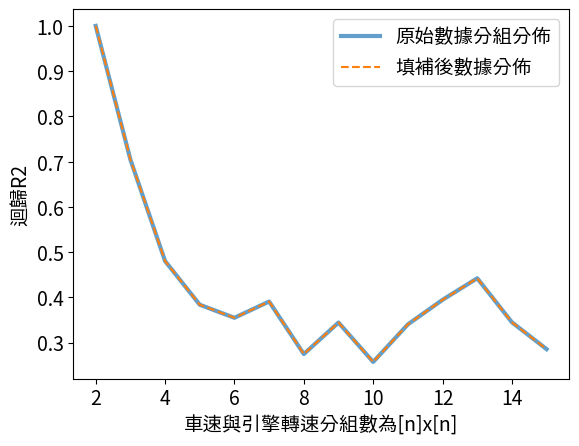

In [29]:
from sklearn.linear_model import LinearRegression
from scipy.interpolate import griddata

spacing_nn = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
r2_scores = {}
r2_scores_new = {}

for nn in spacing_nn:
    ESn = np.linspace(df[df['engine_torque[Nm]']>0]['EngineSpeed[rpm]'].min(), df[df['engine_torque[Nm]']>0]['EngineSpeed[rpm]'].max(), nn+1)
    ETn = np.linspace(df[df['engine_torque[Nm]']>0]['engine_torque[Nm]'].min(), df[df['engine_torque[Nm]']>0]['engine_torque[Nm]'].max(), nn+1)
    dfGG = df.groupby([pd.cut(df[df['engine_torque[Nm]']>0]['EngineSpeed[rpm]'], bins=ESn), pd.cut(df[df['engine_torque[Nm]']>0]['engine_torque[Nm]'], bins=ETn)], observed=True)['BSFC[g/kW-h]'].agg(['count', 'mean', 'median']).reset_index()
    dfGG['BTE'] = 1. / dfGG['median'] * 3600 * 1000 / NCV
    dfGG = dfGG[(dfGG['BTE']<0.838)&(dfGG['BTE']>0)]
    
    dfGG['EngineSpeed[rpm]'] = dfGG['EngineSpeed[rpm]'].apply(lambda x: (x.left+x.right)/2)
    dfGG['engine_torque[Nm]'] = dfGG['engine_torque[Nm]'].apply(lambda x: (x.left+x.right)/2)
    
    X = dfGG[['EngineSpeed[rpm]', 'engine_torque[Nm]']]
    y = dfGG['median']
    reg = LinearRegression().fit(X, y)
    r2_scores[nn] = reg.score(X, y)
    print(f"車速與引擎轉速分組數為{nn}x{nn}下，迴歸的R2為{reg.score(X, y):.4f}")


print()


for nn in spacing_nn:    
    ESn = np.linspace(df[df['engine_torque[Nm]']>0]['EngineSpeed[rpm]'].min(), df[df['engine_torque[Nm]']>0]['EngineSpeed[rpm]'].max(), nn+1)
    ETn = np.linspace(df[df['engine_torque[Nm]']>0]['engine_torque[Nm]'].min(), df[df['engine_torque[Nm]']>0]['engine_torque[Nm]'].max(), nn+1)
    dfGG_new = df.groupby([pd.cut(df[df['engine_torque[Nm]']>0]['EngineSpeed[rpm]'], bins=ESn), pd.cut(df[df['engine_torque[Nm]']>0]['engine_torque[Nm]'], bins=ETn)], observed=False)['BSFC[g/kW-h]'].median().reset_index()
    dfGG_new['BTE'] = 1. / dfGG_new['BSFC[g/kW-h]'] * 3600 * 1000 / NCV
    dfGG_new = dfGG_new[(dfGG_new['BTE']<0.838)&(dfGG_new['BTE']>0)]
    
    dfGG_new['EngineSpeed[rpm]'] = dfGG_new['EngineSpeed[rpm]'].apply(lambda x: (x.left+x.right)/2)
    dfGG_new['engine_torque[Nm]'] = dfGG_new['engine_torque[Nm]'].apply(lambda x: (x.left+x.right)/2)
      
    dfGG_known = dfGG_new.dropna(subset=['BSFC[g/kW-h]'])
    dfGG_missing = dfGG_new[dfGG_new['BSFC[g/kW-h]'].isna()]
    fc_interp = griddata(
        points=dfGG_known[['EngineSpeed[rpm]', 'engine_torque[Nm]']],
        values=dfGG_known['BSFC[g/kW-h]'],
        xi=dfGG_missing[['EngineSpeed[rpm]', 'engine_torque[Nm]']],
        method='nearest'
    )
    dfGG_new.loc[dfGG_new['BSFC[g/kW-h]'].isna(), 'BSFC[g/kW-h]'] = fc_interp

    X = dfGG_new[['EngineSpeed[rpm]', 'engine_torque[Nm]']]
    y = dfGG_new['BSFC[g/kW-h]']
    reg_new = LinearRegression().fit(X, y)
    r2_scores_new[nn] = reg_new.score(X, y)
    print(f"車速與引擎轉速分組數為{nn}x{nn}下(經填補操作)，迴歸的R2為{reg_new.score(X, y):.4f}")


fig = plt.figure() 
plt.plot(spacing_nn, r2_scores.values(), alpha=0.7, linewidth=3, label="原始數據分組分佈")
plt.plot(spacing_nn, r2_scores_new.values(), linestyle='--', label="填補後數據分佈")
plt.xlabel('車速與引擎轉速分組數為[n]x[n]')
plt.ylabel('迴歸R2')
plt.legend()
plt.show()

### 使用方式二(nn=8)

In [30]:
nn = 8

ESn = np.linspace(df[df['engine_torque[Nm]']>0]['EngineSpeed[rpm]'].min(), df[df['engine_torque[Nm]']>0]['EngineSpeed[rpm]'].max(), nn+1)
ETn = np.linspace(df[df['engine_torque[Nm]']>0]['engine_torque[Nm]'].min(), df[df['engine_torque[Nm]']>0]['engine_torque[Nm]'].max(), nn+1)
dfGG = df.groupby([pd.cut(df[df['engine_torque[Nm]']>0]['EngineSpeed[rpm]'], bins=ESn), pd.cut(df[df['engine_torque[Nm]']>0]['engine_torque[Nm]'], bins=ETn)], observed=True)['BSFC[g/kW-h]'].agg(['count', 'mean', 'median']).reset_index()

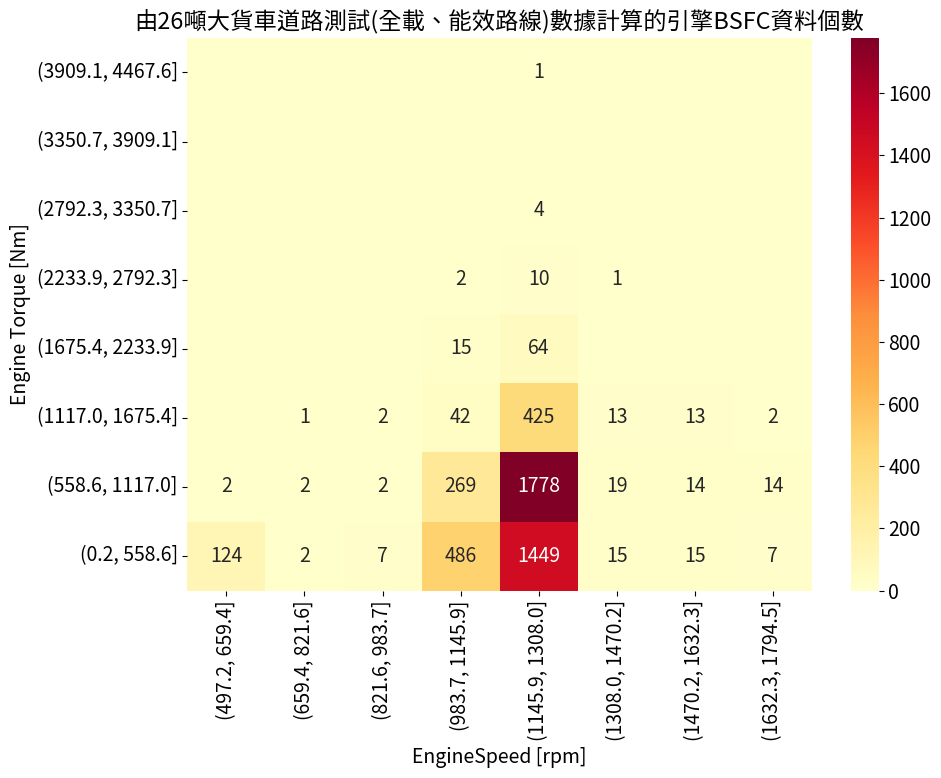

In [31]:
# 分組統計
dfGG = df[df['engine_torque[Nm]'] > 0].groupby(
    [pd.cut(df[df['engine_torque[Nm]'] > 0]['EngineSpeed[rpm]'], bins=ESn),
     pd.cut(df[df['engine_torque[Nm]'] > 0]['engine_torque[Nm]'], bins=ETn)],
    observed=True
)['BSFC[g/kW-h]'].agg(['count', 'mean', 'median']).reset_index()

# 取得所有分類區間
all_rpm_bins = pd.cut(df['EngineSpeed[rpm]'], bins=ESn).cat.categories
all_torque_bins = pd.cut(df['engine_torque[Nm]'], bins=ETn).cat.categories

# 建立完整空白框架，補齊所有可能組合
full_index = pd.MultiIndex.from_product([all_torque_bins, all_rpm_bins],
                                        names=['engine_torque[Nm]', 'EngineSpeed[rpm]'])

# 將現有 dfGG 補齊所有分箱
dfGG_full = dfGG.set_index(['engine_torque[Nm]', 'EngineSpeed[rpm]']).reindex(full_index).fillna(0).reset_index()

# 建立 pivot table，缺值已填 0
pivot_table_count = dfGG_full.pivot_table(
    index='engine_torque[Nm]',
    columns='EngineSpeed[rpm]',
    values='count',
    observed=True,
    fill_value=0
)

# 先建立 annot 的文字矩陣（跟 pivot_table_count 相同 shape）
annot_matrix = pivot_table_count.copy()
annot_matrix = annot_matrix.map(lambda x: f"{int(x)}" if x != 0 else "")

# 繪製熱力圖
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    pivot_table_count,
    annot=annot_matrix,      # 使用自訂註記內容
    fmt='',                  # 不使用 seaborn 的內建格式（因為你已經自己格式化）
    cmap='YlOrRd',
    # cbar_kws={"label": "資料個數"}
)
ax.invert_yaxis()
plt.title(f"由26噸大貨車道路測試({testing_load_c}、能效路線)數據計算的引擎BSFC資料個數")
plt.xlabel("EngineSpeed [rpm]")
plt.ylabel("Engine Torque [Nm]")

# 保留原來的區間格式 (a, b]，但格式化為小數點一位
ax.set_xticklabels([f"({interval.left:.1f}, {interval.right:.1f}]" for interval in pivot_table_count.columns])
ax.set_yticklabels([f"({interval.left:.1f}, {interval.right:.1f}]" for interval in pivot_table_count.index])

plt.tight_layout()
plt.show()


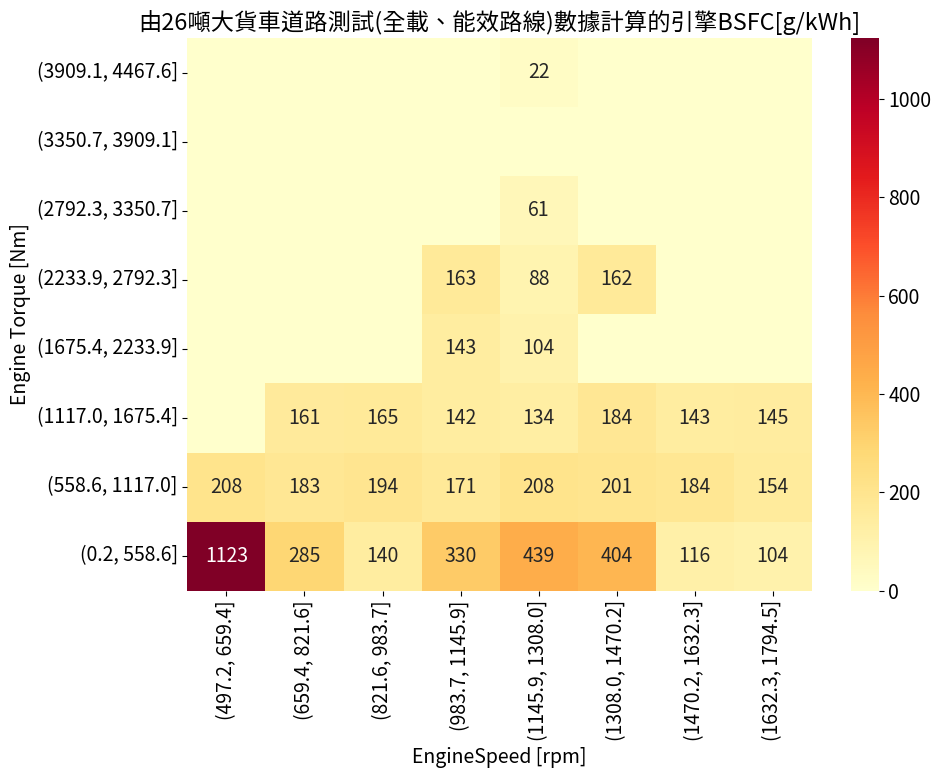

In [32]:
# 建立 pivot table，缺值已填 0
pivot_table_count = dfGG_full.pivot_table(
    index='engine_torque[Nm]',
    columns='EngineSpeed[rpm]',
    values='median',
    observed=True,
    fill_value=0
)

# 先建立 annot 的文字矩陣（跟 pivot_table_count 相同 shape）
annot_matrix = pivot_table_count.copy()
annot_matrix = annot_matrix.map(lambda x: f"{int(x)}" if x != 0 else "")

# 繪製熱力圖
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    pivot_table_count,
    annot=annot_matrix,      # 使用自訂註記內容
    fmt='',                  # 不使用 seaborn 的內建格式（因為你已經自己格式化）
    cmap='YlOrRd',
    # cbar_kws={"label": "BSFC"}
)
ax.invert_yaxis()
plt.title(f"由26噸大貨車道路測試({testing_load_c}、能效路線)數據計算的引擎BSFC[g/kWh]")
plt.xlabel("EngineSpeed [rpm]")
plt.ylabel("Engine Torque [Nm]")

# 保留原來的區間格式 (a, b]，但格式化為小數點一位
ax.set_xticklabels([f"({interval.left:.1f}, {interval.right:.1f}]" for interval in pivot_table_count.columns])
ax.set_yticklabels([f"({interval.left:.1f}, {interval.right:.1f}]" for interval in pivot_table_count.index])

plt.tight_layout()
plt.show()

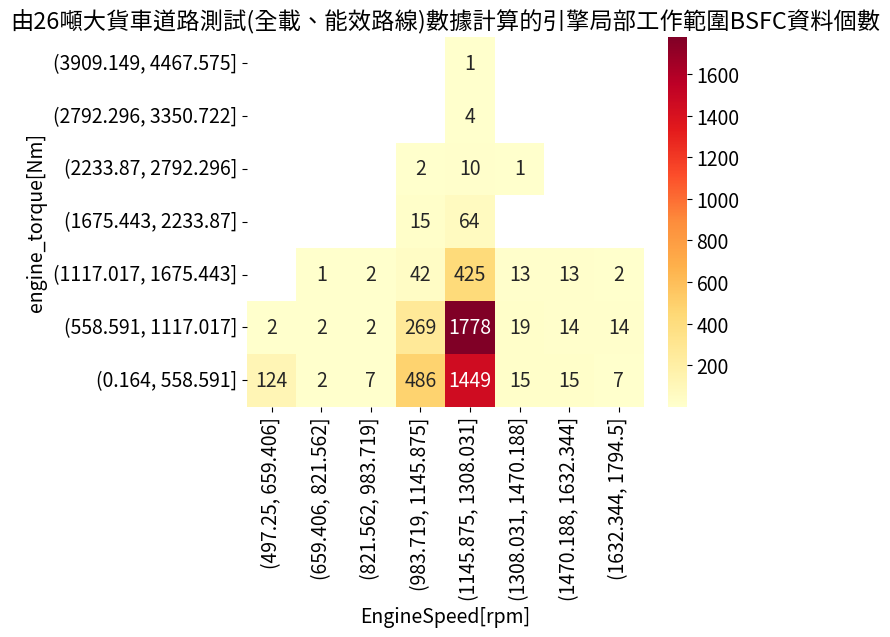

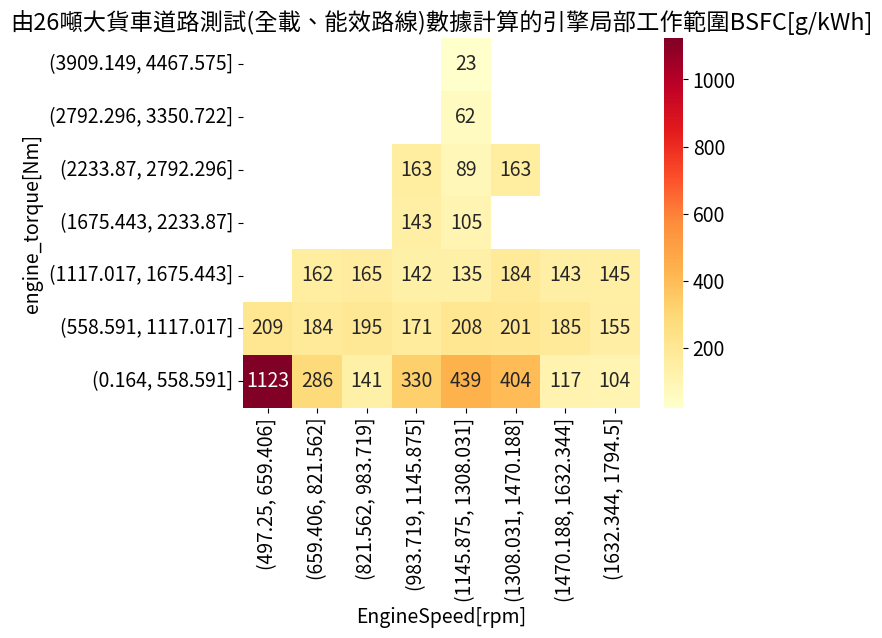

In [33]:
pivot_table_count = dfGG.pivot(index='engine_torque[Nm]', columns='EngineSpeed[rpm]', values='count')
plt.figure()
ax = sns.heatmap(pivot_table_count, annot=True, fmt='.0f', cmap='YlOrRd')
ax.invert_yaxis()
plt.title(f"由26噸大貨車道路測試({testing_load_c}、能效路線)數據計算的引擎局部工作範圍BSFC資料個數")
plt.show()

pivot_table_count = dfGG.pivot(index='engine_torque[Nm]', columns='EngineSpeed[rpm]', values='median')
plt.figure()
ax = sns.heatmap(pivot_table_count, annot=True, fmt='.0f', cmap='YlOrRd')
ax.invert_yaxis()
plt.title(f"由26噸大貨車道路測試({testing_load_c}、能效路線)數據計算的引擎局部工作範圍BSFC[g/kWh]")
plt.show()

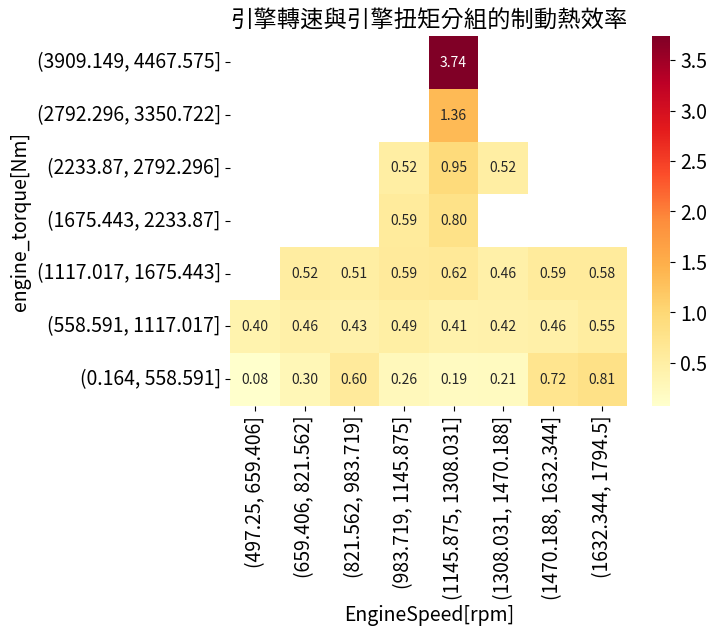

In [34]:
# Brake Thermal Efficiency, BTE
# 可進一步依照BTE篩選合理數據
dfGG['BTE'] = 1. / dfGG['median'] * 3600 * 1000 / NCV # 熱值NCV為42700 kJ/kg
# dfGG = dfGG[(dfGG['BTE']<1)&(dfGG['BTE']>0)]

pivot_table_count = dfGG.pivot(index='engine_torque[Nm]', columns='EngineSpeed[rpm]', values='BTE')
plt.figure()
ax = sns.heatmap(pivot_table_count, annot=True, fmt='.2f', cmap='YlOrRd', annot_kws={"size": 10})
ax.invert_yaxis()
plt.title(f"引擎轉速與引擎扭矩分組的制動熱效率")
plt.show()

In [35]:
dfGG.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   EngineSpeed[rpm]   30 non-null     category
 1   engine_torque[Nm]  30 non-null     category
 2   count              30 non-null     int64   
 3   mean               30 non-null     float64 
 4   median             30 non-null     float64 
 5   BTE                30 non-null     float64 
dtypes: category(2), float64(3), int64(1)
memory usage: 2.3 KB


In [36]:
dfGG[['count', 'mean', 'median']].describe()

,count,mean,median
count,30.000000,30.000000,30.000000
mean,160.000000,417.133799,209.232309
std,415.447993,836.667668,193.962059
min,1.000000,22.546998,22.546998
25%,2.000000,150.215593,141.189575
50%,13.000000,167.267504,162.883122
75%,36.250000,213.082644,199.515633
max,1778.000000,4494.693516,1123.312464


<Axes: >

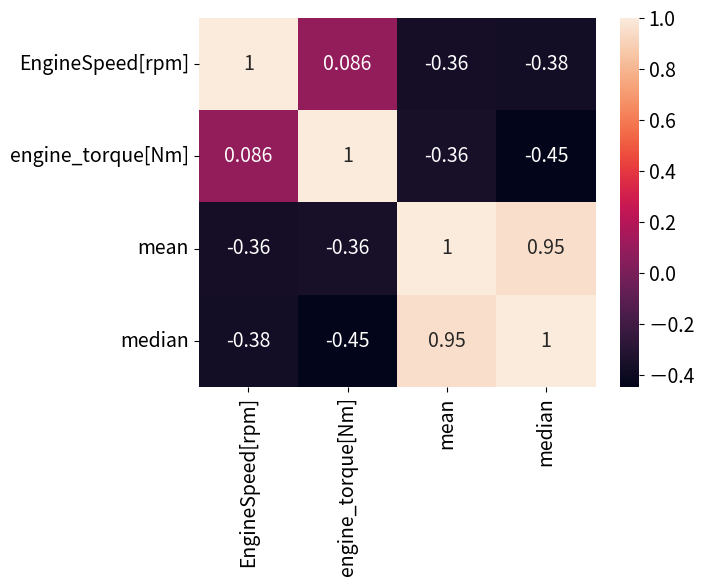

In [40]:
sns.heatmap(dfGG[['EngineSpeed[rpm]', 'engine_torque[Nm]', 'mean', 'median']].corr(), annot=True)

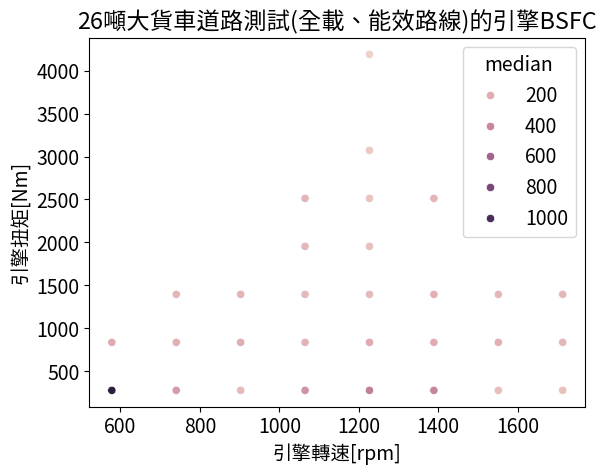

In [37]:
dfGG['EngineSpeed[rpm]'] = dfGG['EngineSpeed[rpm]'].apply(lambda x: (x.left+x.right)/2)
dfGG['engine_torque[Nm]'] = dfGG['engine_torque[Nm]'].apply(lambda x: (x.left+x.right)/2)

fig = plt.figure()
sns.scatterplot(data=dfGG,
                x="EngineSpeed[rpm]",
                y="engine_torque[Nm]",
                hue="median")

plt.title(f"26噸大貨車道路測試({testing_load_c}、能效路線)的引擎BSFC")
# plt.ylim(0,3000)
plt.gca().invert_yaxis()
plt.xlabel('引擎轉速[rpm]')
plt.ylabel('引擎扭矩[Nm]')

plt.show()

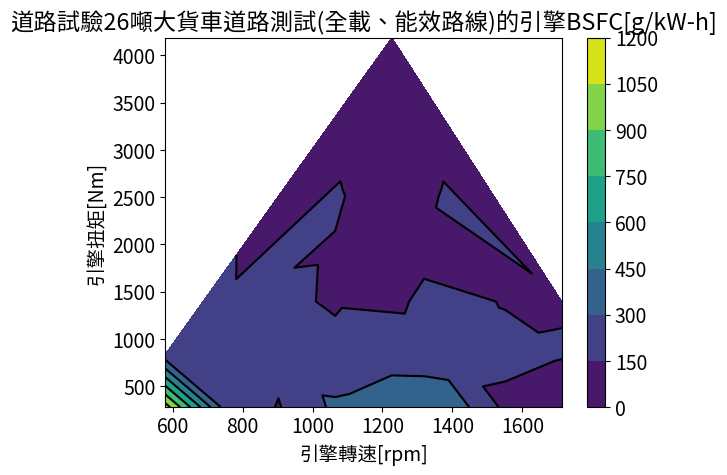

In [38]:
fig = plt.figure()
tcf = plt.tricontourf(dfGG["EngineSpeed[rpm]"],
                      dfGG["engine_torque[Nm]"],
                      dfGG["median"])
fig.colorbar(tcf)
plt.tricontour(dfGG["EngineSpeed[rpm]"],
               dfGG["engine_torque[Nm]"],
               dfGG["median"],
               colors='k')
plt.title(f"道路試驗26噸大貨車道路測試({testing_load_c}、能效路線)的引擎BSFC[g/kW-h]")
plt.xlabel('引擎轉速[rpm]')
plt.ylabel('引擎扭矩[Nm]')
plt.show()

In [39]:
dfGG.to_csv(f"..\\models\\model_6_spacing_{nn}x{nn}_{testing_load}.csv", encoding= 'utf-8-sig', index=False)

In [50]:
list(dfGG['median'].sort_values()) # 雖然知道有這種情況，但目前版本仍然沒有進行人工調整

[22.546998304276087,
 61.95849814884566,
 88.92489107470004,
 104.26089868923228,
 104.95821814318406,
 116.97335921706683,
 134.97523319227304,
 140.85724703944794,
 142.18655710064357,
 143.3742226823829,
 143.4389758056738,
 145.39169078443587,
 154.5538564178481,
 161.8297973404354,
 162.73893403553316,
 163.02731044336076,
 165.23810985513657,
 171.05509459733972,
 183.54962833694702,
 184.2633399831054,
 184.9345490696571,
 194.99069298630542,
 201.02394587837858,
 208.15765180735164,
 208.57826605222726,
 285.77124621321985,
 330.4112215110838,
 404.3918320669161,
 439.2945488966863,
 1123.312464381658]

In [41]:
from sklearn.linear_model import LinearRegression

X = dfGG[['EngineSpeed[rpm]', 'engine_torque[Nm]']]
y = dfGG['median']

reg = LinearRegression().fit(X, y)
print(f"車速與引擎轉速分組數為{nn}x{nn}下，迴歸的R2為{reg.score(X, y):.4f}")
print(reg.coef_)
print(reg.intercept_)

車速與引擎轉速分組數為8x8下，迴歸的R2為0.3163
[-0.20294894 -0.08475844]
554.0889057356255


## 運用二維插值

[161.82979734 143.37422268 163.02731044  61.95849815  61.95849815
  22.5469983  143.37422268 163.02731044  61.95849815  61.95849815
  22.5469983  143.37422268 163.02731044  61.95849815  61.95849815
  22.5469983   61.95849815  61.95849815  22.5469983   61.95849815
 104.95821814  61.95849815  61.95849815  22.5469983  104.95821814
 162.73893404  61.95849815  61.95849815  22.5469983  104.95821814
 162.73893404  61.95849815  61.95849815  22.5469983 ]


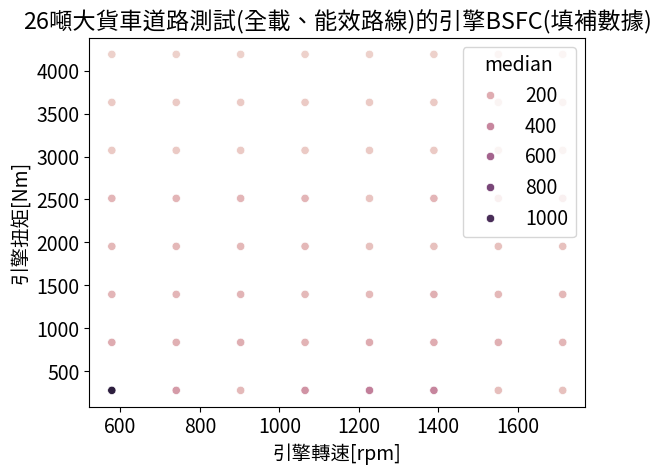

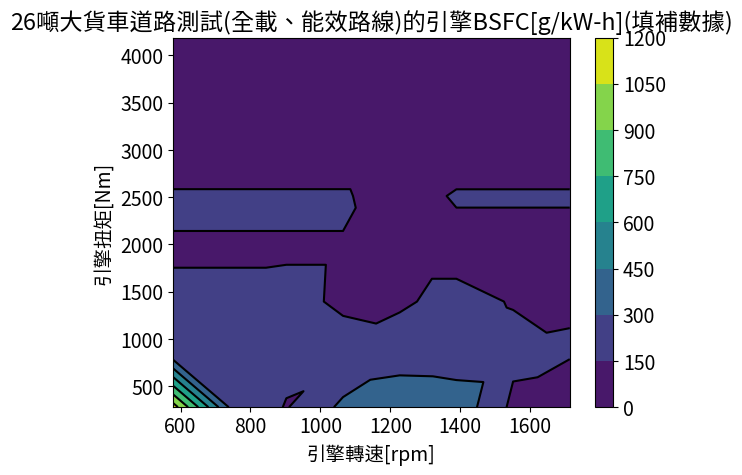

In [42]:
from scipy.interpolate import griddata


dfGG_new = df.groupby([pd.cut(df[df['engine_torque[Nm]']>0]['EngineSpeed[rpm]'], bins=ESn), pd.cut(df[df['engine_torque[Nm]']>0]['engine_torque[Nm]'], bins=ETn)], observed=False)['BSFC[g/kW-h]'].agg(['count', 'mean', 'median']).reset_index()
dfGG_new['BTE'] = 1. / dfGG_new['median'] * 3600 * 1000 / NCV
# dfGG_new = dfGG_new[(dfGG_new['BTE']<1)&(dfGG_new['BTE']>0)]
dfGG_new['EngineSpeed_left[rpm]'] = dfGG_new['EngineSpeed[rpm]'].apply(lambda x: x.left)
dfGG_new['EngineSpeed_right[rpm]'] = dfGG_new['EngineSpeed[rpm]'].apply(lambda x: x.right)
dfGG_new['EngineSpeed[rpm]'] = dfGG_new['EngineSpeed[rpm]'].apply(lambda x: (x.left+x.right)/2)
dfGG_new['engine_torque_left[Nm]'] = dfGG_new['engine_torque[Nm]'].apply(lambda x: x.left)
dfGG_new['engine_torque_right[Nm]'] = dfGG_new['engine_torque[Nm]'].apply(lambda x: x.right)
dfGG_new['engine_torque[Nm]'] = dfGG_new['engine_torque[Nm]'].apply(lambda x: (x.left+x.right)/2)


dfGG_known = dfGG_new.dropna(subset=['median'])
dfGG_missing = dfGG_new[dfGG_new['median'].isna()]
# print(list(dfGG_known.index), len(dfGG_known))
# print(list(dfGG_missing.index), len(dfGG_missing))

fc_interp = griddata(
    points=dfGG_known[['EngineSpeed[rpm]', 'engine_torque[Nm]']],
    values=dfGG_known['median'],
    xi=dfGG_missing[['EngineSpeed[rpm]', 'engine_torque[Nm]']],
    method='nearest'  # 可選 'linear', 'nearest', 'cubic'
)
print(fc_interp)

dfGG_new.loc[dfGG_new['median'].isna(), 'median'] = fc_interp
# print(dfGG_new)


fig = plt.figure()
sns.scatterplot(data=dfGG_new,
                x="EngineSpeed[rpm]",
                y="engine_torque[Nm]",
                hue="median")

plt.title(f"26噸大貨車道路測試({testing_load_c}、能效路線)的引擎BSFC(填補數據)")
# plt.ylim(0,3000)
plt.gca().invert_yaxis()
plt.xlabel('引擎轉速[rpm]')
plt.ylabel('引擎扭矩[Nm]')

plt.show()


fig = plt.figure()
tcf = plt.tricontourf(dfGG_new["EngineSpeed[rpm]"],
                      dfGG_new["engine_torque[Nm]"],
                      dfGG_new["median"])
fig.colorbar(tcf)
plt.tricontour(dfGG_new["EngineSpeed[rpm]"],
               dfGG_new["engine_torque[Nm]"],
               dfGG_new["median"],
               colors='k')
plt.title(f"26噸大貨車道路測試({testing_load_c}、能效路線)的引擎BSFC[g/kW-h](填補數據)")
plt.xlabel('引擎轉速[rpm]')
plt.ylabel('引擎扭矩[Nm]')
plt.show()

In [43]:
dfGG_new.to_csv(f"..\\models\\model_6_spacing_{nn}x{nn}_{testing_load}(填補).csv", encoding= 'utf-8-sig', index=False)
print(dfGG_new)

   EngineSpeed[rpm] engine_torque[Nm]  count         mean       median  \
0           578.328          279.3775    124  4494.693516  1123.312464   
1           578.328          837.8040      2   208.578266   208.578266   
2           578.328         1396.2300      0          NaN   161.829797   
3           578.328         1954.6565      0          NaN   143.374223   
4           578.328         2513.0830      0          NaN   163.027310   
..              ...               ...    ...          ...          ...   
59         1713.422         1954.6565      0          NaN   104.958218   
60         1713.422         2513.0830      0          NaN   162.738934   
61         1713.422         3071.5090      0          NaN    61.958498   
62         1713.422         3629.9355      0          NaN    61.958498   
63         1713.422         4188.3620      0          NaN    22.546998   

         BTE EngineSpeed_left[rpm] EngineSpeed_right[rpm]  \
0   0.075054               497.250                

<Axes: >

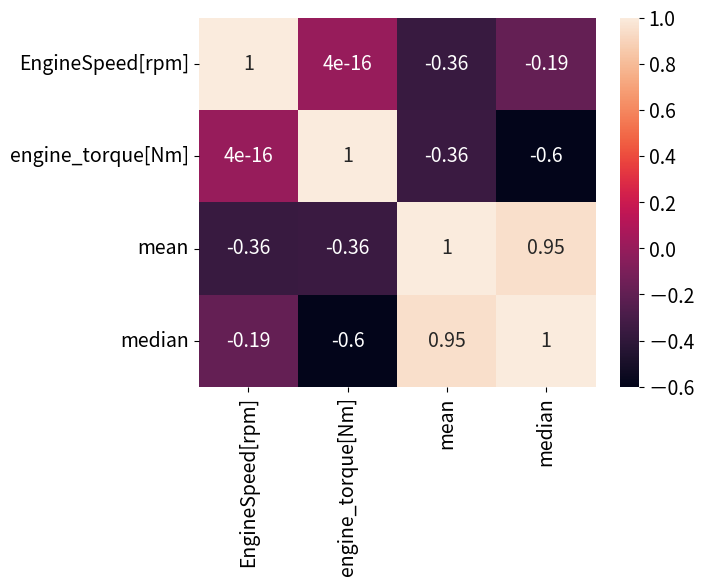

In [44]:
sns.heatmap(dfGG_new[['EngineSpeed[rpm]', 'engine_torque[Nm]', 'mean', 'median']].corr(), annot=True)

In [45]:
from sklearn.linear_model import LinearRegression

X = dfGG_new[['EngineSpeed[rpm]', 'engine_torque[Nm]']]
y = dfGG_new['median']

reg_new = LinearRegression().fit(X, y)
print(f"引擎轉速與引擎扭矩分組數為{nn}x{nn}下，迴歸的R2為{reg_new.score(X, y):.4f}")
print(reg_new.coef_)
print(reg_new.intercept_)

引擎轉速與引擎扭矩分組數為8x8下，迴歸的R2為0.3983
[-0.07565586 -0.07036326]
385.83641632000825


In [46]:
df['預測BSFC[g/kWh]'] = reg_new.predict(df[['EngineSpeed[rpm]', 'engine_torque[Nm]']])
df['預測燃油流量[L/h]'] = df['預測BSFC[g/kWh]'] * df['engine_power[kW]'] / 1000. / density_deisel * 1000.
df.loc[df['預測燃油流量[L/h]']<0, '預測燃油流量[L/h]'] = 0
print(f"量測用油{df['EngineFuelRate[L/h]'].sum()/3600:.2f}公升")
print(f"預測用油{df['預測燃油流量[L/h]'].sum()/3600:.2f}公升")
print(f"行駛{df['VehicleSpeed[km/h]'].sum()/3.6/1000:.2f}公里")

量測用油32.40公升
預測用油30.23公升
行駛106.16公里


In [47]:
print(f"量測能效{(df['VehicleSpeed[km/h]'].sum()/3.6/1000)/(df['EngineFuelRate[L/h]'].sum()/3600):.2f}公里/公升")
print(f"預測能效{(df['VehicleSpeed[km/h]'].sum()/3.6/1000)/(df['預測燃油流量[L/h]'].sum()/3600):.2f}公里/公升")

量測能效3.28公里/公升
預測能效3.51公里/公升


In [48]:
import pickle

with open(f'..\\models\\model_6_spacing_{nn}x{nn}_{testing_load}.pkl', 'wb') as f:
    pickle.dump(reg_new, f)